# FastFarmInterface: Python-FAST.Farm 统一接口

## Prerequisites

本 notebook 使用标准 Python kernel（无需 MPI）。
`FastFarmInterface` 以 subprocess 方式运行 FAST.Farm，支持在线闭环控制。

In [1]:
# UNCOMMENT TO INSTALL WFCRL Kernel
#from wfcrl import jupyter_utils
#jupyter_utils.create_ipykernel()

A standard Python 3 kernel is sufficient (e.g., the `wfcrl` virtual environment kernel).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tempfile, os

from wfcrl.config import WindConfig, ControlInput
from wfcrl.interface import FastFarmInterface
from wfcrl.environments.data_cases import named_cases_dictionary

sns.set_theme(style="darkgrid")

## Farm configuration

In the following, it is assumed that you have a local FastFarm executable. Start by updating the path to this `exe` file below.

In [3]:
# FAST.Farm v5.0.0 可执行文件路径（可通过环境变量 FAST_FARM_EXE 设置）
import os as _os
FAST_FARM_EXECUTABLE = _os.environ.get("FAST_FARM_EXE", "simulators/fastfarm/bin/FAST.Farm_x64_OMP.exe")

The library comes with a list of pre-existing farm layouts that can be found in `environments/data_cases.py` and uses directly to create an interface:

In [4]:
# 选择预设案例: DafengH1, Ablaincourt, Turb6_Row2 等
CASE_NAME = "DafengH1"
base_case = named_cases_dictionary[CASE_NAME + "_"][0]  # [0]=FAST.Farm 案例
n_turbs = base_case.num_turbines

# ---- 统一风况配置 ----
wind = WindConfig(speed=10, direction=270)

# ---- 仿真配置 ----
from wfcrl.simul_config import FastFarmConfig
output_dir = os.path.join(tempfile.gettempdir(), "wfcrl_interface_demo")
config = FastFarmConfig(
    case_name=CASE_NAME,
    num_turbines=n_turbs,
    xcoords=base_case.xcoords,
    ycoords=base_case.ycoords,
    dt=3,
    max_iter=5,
    wind=wind,
    output_dir=output_dir,
)

# ---- 创建接口 ----
ff = FastFarmInterface(config)
ff.setup()
ff.reset(wind)
print(f"Case: {CASE_NAME} ({ff.n_turbines} turbines)")
print(f"Files in: {config.output_dir}")

Deltas: [ 2.01534455e-03  2.00536760e-03  2.00536760e-03  2.00536760e-03
  2.00536760e-03  2.00536760e-03  2.00536760e-03  1.50651994e-03
  9.97695324e-04  4.88870709e-04  9.97695324e-04  9.97695324e-04
  9.97695324e-04  9.97695324e-04  9.97695324e-04  1.33691173e-03
  6.68455867e-04 -1.99539065e-05 -1.99539065e-05 -9.97695322e-06
 -9.97695322e-06 -9.97695324e-06  1.13242749e-14 -5.98617194e-05]
Exception has been raise. I put this print statement instead. Check with EB.
Exception: Some Y0_High are not on an integer multiple of the high-res grid
Created FAST.Farm input file: C:\Users\Freeman\AppData\Local\Temp\wfcrl_interface_demo/FarmInputs/Case.fstf
Case: DafengH1 (24 turbines)
Files in: C:\Users\Freeman\AppData\Local\Temp\wfcrl_interface_demo


Alternatively, you can create your own layout with `FastFarmCase` and use `create_ff_case` to create all the configuration files needed to run FAST.Farm.

In [5]:
# 也可以创建自定义布局
from wfcrl.config import WindConfig
from wfcrl.simul_config import FastFarmConfig

custom_config = FastFarmConfig(
    case_name="custom_3t",
    num_turbines=3,
    xcoords=[0.0, 504.0, 1008.0],
    ycoords=[0.0, 0.0, 0.0],
    dt=3,
    max_iter=10,
    wind=WindConfig(speed=10, direction=270),
)

custom_dir = os.path.join(tempfile.gettempdir(), "wfcrl_custom_demo")
custom_config.output_dir = custom_dir

ff_custom = FastFarmInterface(custom_config)
ff_custom.setup()
ff_custom.reset(custom_config.wind)
print(f"Custom case files in: {custom_config.output_dir}")

Created FAST.Farm input file: C:\Users\Freeman\AppData\Local\Temp\wfcrl_custom_demo/FarmInputs/Case.fstf
Custom case files in: C:\Users\Freeman\AppData\Local\Temp\wfcrl_custom_demo


Then, make the FAST.Farm interface with the created file or your own `.fstf`.

In [6]:
# 接口已就绪，可用 step() 单步运行或 run() 批量运行
print(f"Turbines: {ff.n_turbines}")

# 单步运行:
# output = ff.step(ControlInput.scalar(ff.n_turbines, yaw_deg=0, pitch_deg=0))
# print(f"Farm power: {output.farm_power_mw[-1]:.2f} MW")

# 批量运行:
# controls = [ControlInput.scalar(ff.n_turbines, yaw_deg=0, pitch_deg=0)] * 5
# output = ff.run(controls)
# See example_hycon_farm_control.py for full usage.

Turbines: 24


The case files are generated in a temporary directory. The .fstf file and all turbine input files are ready for FAST.Farm simulation. Results are parsed automatically when calling `ff_interface.run()`.

## Start simulation

Set yaw and pitch angles, then run the simulation. The interface automatically generates input files, runs FAST.Farm, and parses the output.

In [7]:
# 批量运行仿真并收集输出
# FastFarmInterface 以 subprocess 运行 FAST.Farm，每一步生成独立的 .fstf。
# 若需实时控制，直接在循环中调用 ff.step(controls)。

controls = [ControlInput.scalar(n_turbs, yaw_deg=0.0, pitch_deg=0.0)] * ff.config.max_iter
output = ff.run(controls)

if output.power_mw is not None and output.power_mw.size > 0:
    time_vec = output.time
    farm_power = output.farm_power_mw
    print(f"Simulation completed: {len(time_vec)} time steps")
    print(f"Farm power range: {farm_power.min():.2f} - {farm_power.max():.2f} MW")
else:
    print("No power data collected")

Deltas: [ 2.01534455e-03  2.00536760e-03  2.00536760e-03  2.00536760e-03
  2.00536760e-03  2.00536760e-03  2.00536760e-03  1.50651994e-03
  9.97695324e-04  4.88870709e-04  9.97695324e-04  9.97695324e-04
  9.97695324e-04  9.97695324e-04  9.97695324e-04  1.33691173e-03
  6.68455867e-04 -1.99539065e-05 -1.99539065e-05 -9.97695322e-06
 -9.97695322e-06 -9.97695324e-06  1.13242749e-14 -5.98617194e-05]
Exception has been raise. I put this print statement instead. Check with EB.
Exception: Some Y0_High are not on an integer multiple of the high-res grid
Created FAST.Farm input file: C:\Users\Freeman\AppData\Local\Temp\wfcrl_interface_demo\step_0000/FarmInputs/Case.fstf
Deltas: [ 2.01534455e-03  2.00536760e-03  2.00536760e-03  2.00536760e-03
  2.00536760e-03  2.00536760e-03  2.00536760e-03  1.50651994e-03
  9.97695324e-04  4.88870709e-04  9.97695324e-04  9.97695324e-04
  9.97695324e-04  9.97695324e-04  9.97695324e-04  1.33691173e-03
  6.68455867e-04 -1.99539065e-05 -1.99539065e-05 -9.97695322e-

## Plots and data

All the measurements are available with the method `get_all_measures()` and stored in `raw_measures` in our case.

In [8]:
# 显示最后时刻每台风机的功率
if output.power_mw is not None and output.power_mw.size > 0:
    df_power = pd.DataFrame({
        'turbine': [f"T{i+1}" for i in range(ff.n_turbines)],
        'power_MW': output.power_mw[-1, :] if output.power_mw.ndim > 1 else output.power_mw
    })
    df_power

In [9]:
# 创建功率数据 DataFrame
if output.power_mw is not None and output.power_mw.size > 0:
    n_turb = output.power_mw.shape[1]
    cols = [f"T{i+1}_power_MW" for i in range(n_turb)]
    df = pd.DataFrame(output.power_mw, columns=cols)
    df["time_s"] = output.time
    df["total_MW"] = df.sum(axis=1)
    df.head()

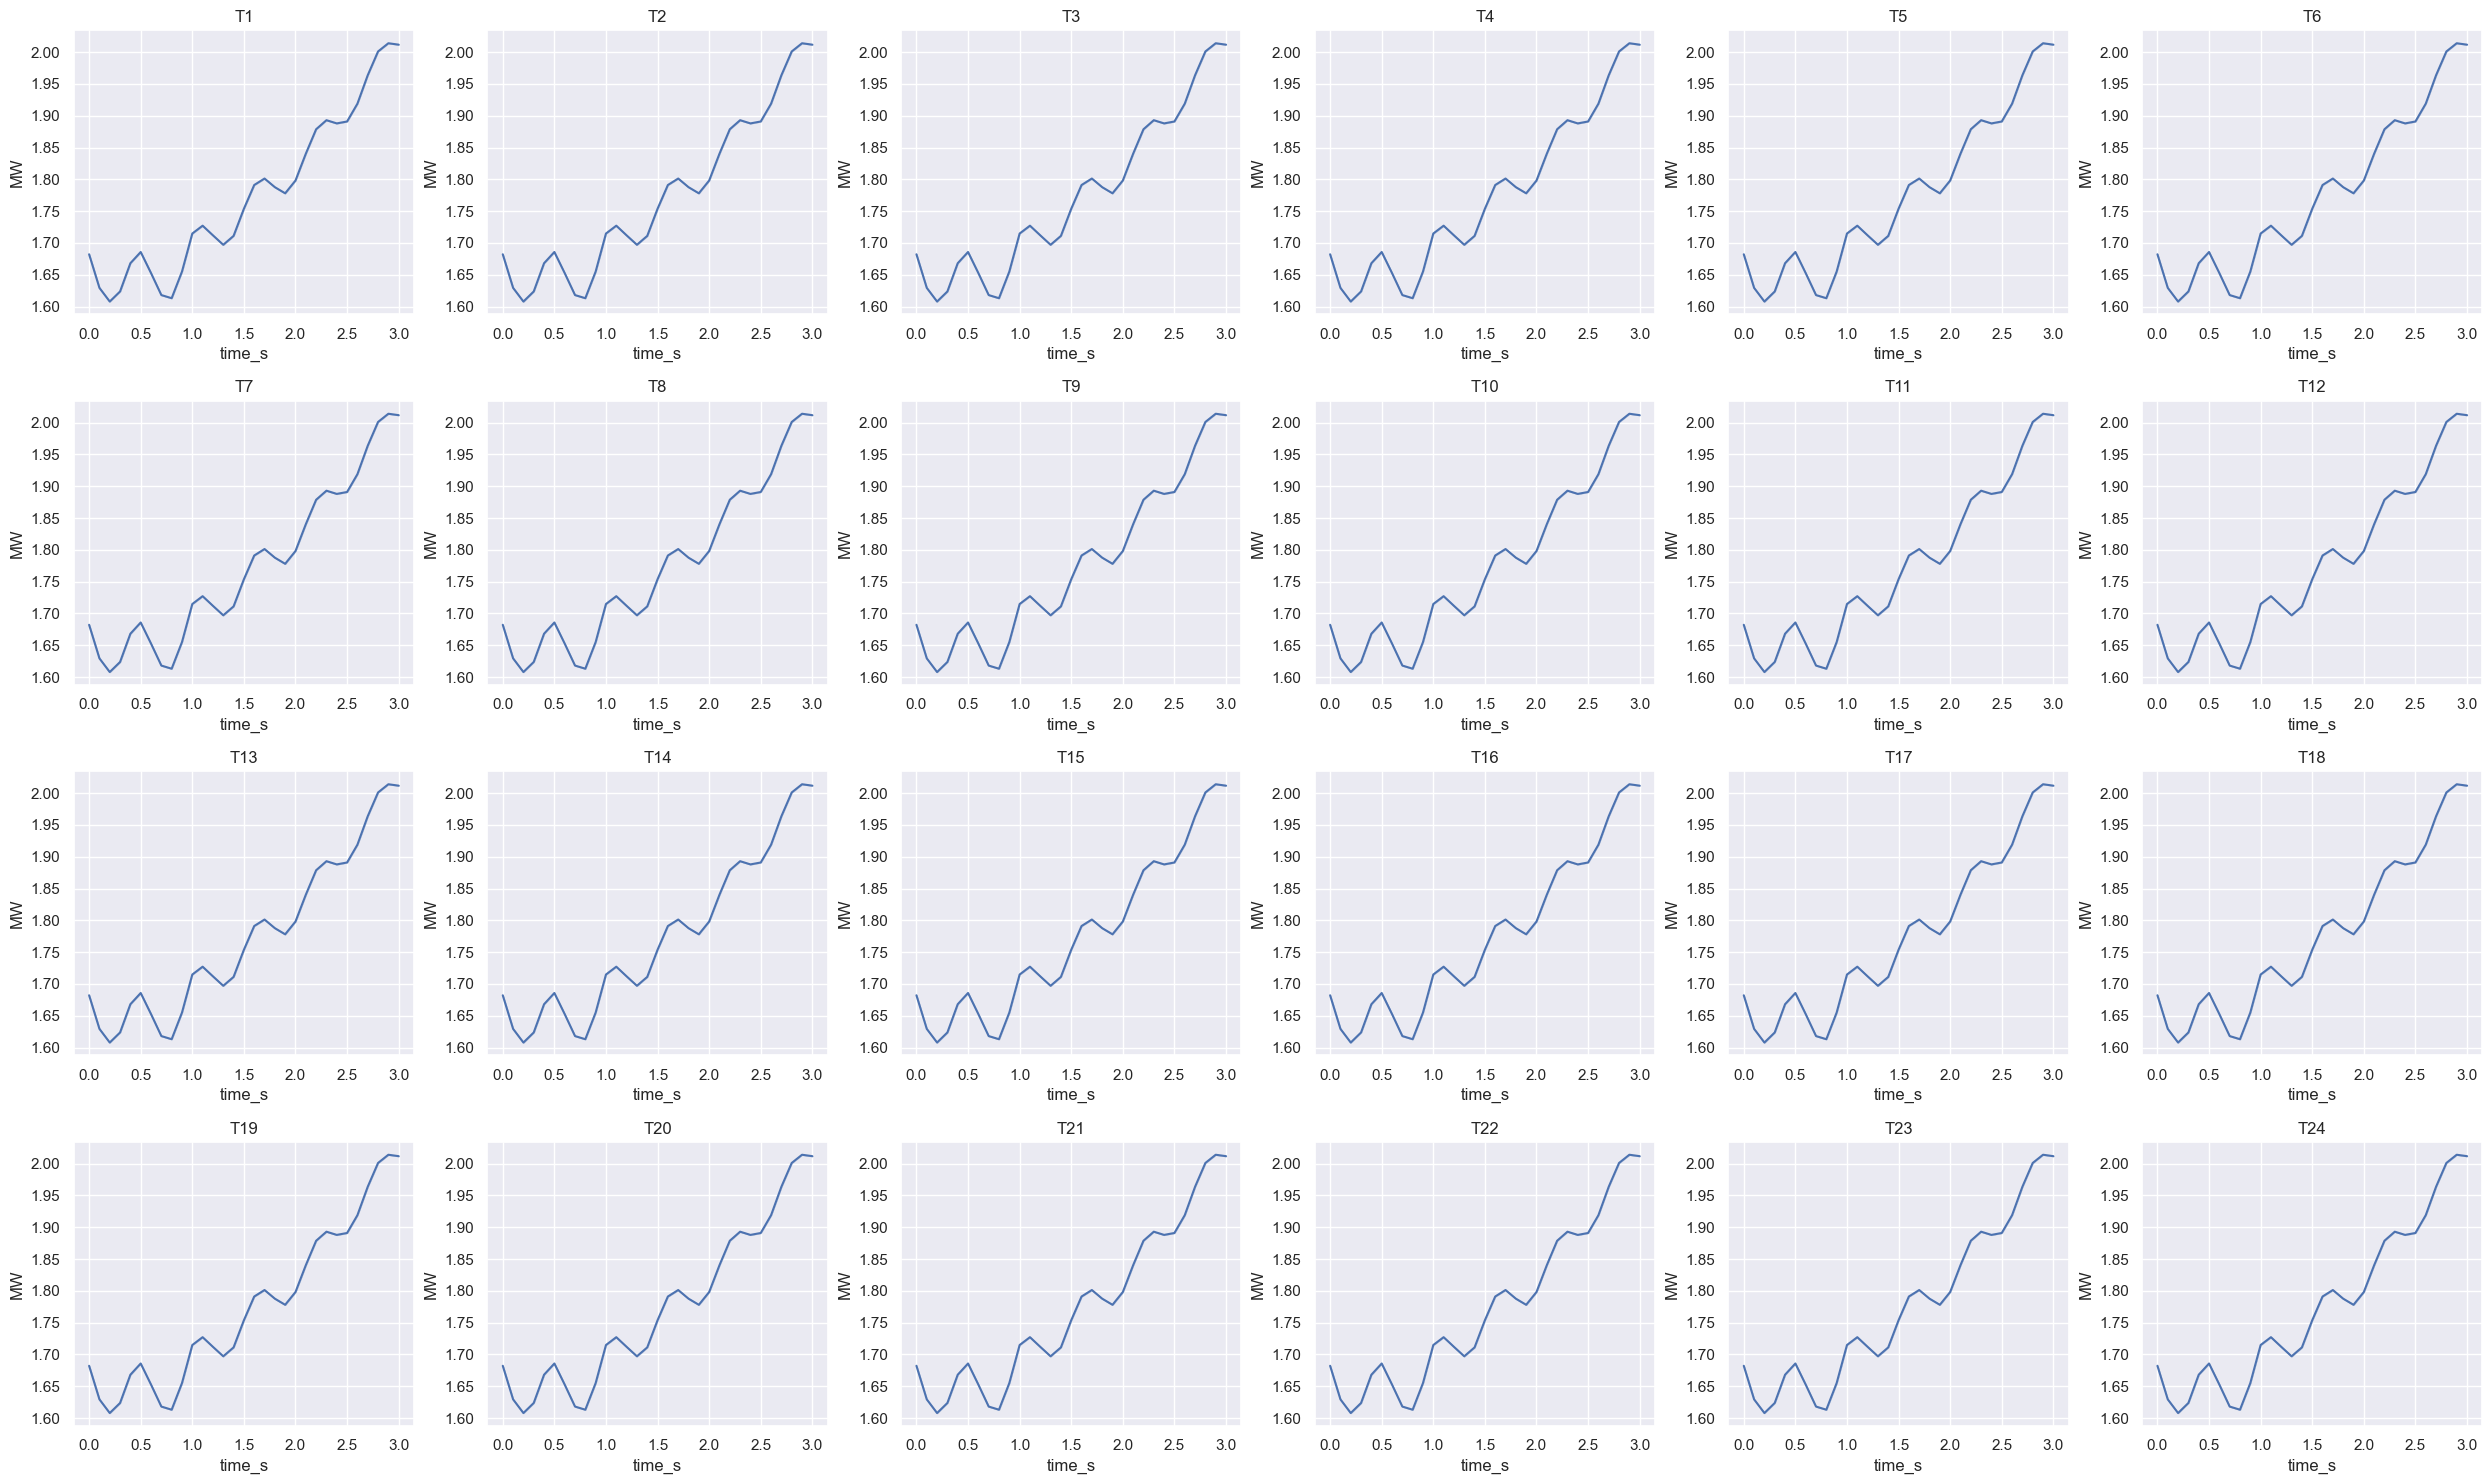

In [11]:
# Plot individual turbine power and total farm power
if 'df' in locals():
    fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(25, 15))
    for i, ax in enumerate(axes.flatten()):
        if i < ff.n_turbines:
            col = f"T{i+1}_power_MW"
            sns.lineplot(df, x="time_s", y=col, ax=ax)
            ax.set_title(f"T{i+1}")
            ax.set_ylabel("MW")
        else:
            ax.set_visible(False)
    plt.tight_layout()

Power measurements are returned as a numpy array from `measurements['power_mw']`, with shape (n_time_steps, n_turbines). The time vector is in `measurements['time']`. Use `import wfcrl.interface.FastFarmOnlineInterface` for step-by-step online optimization.

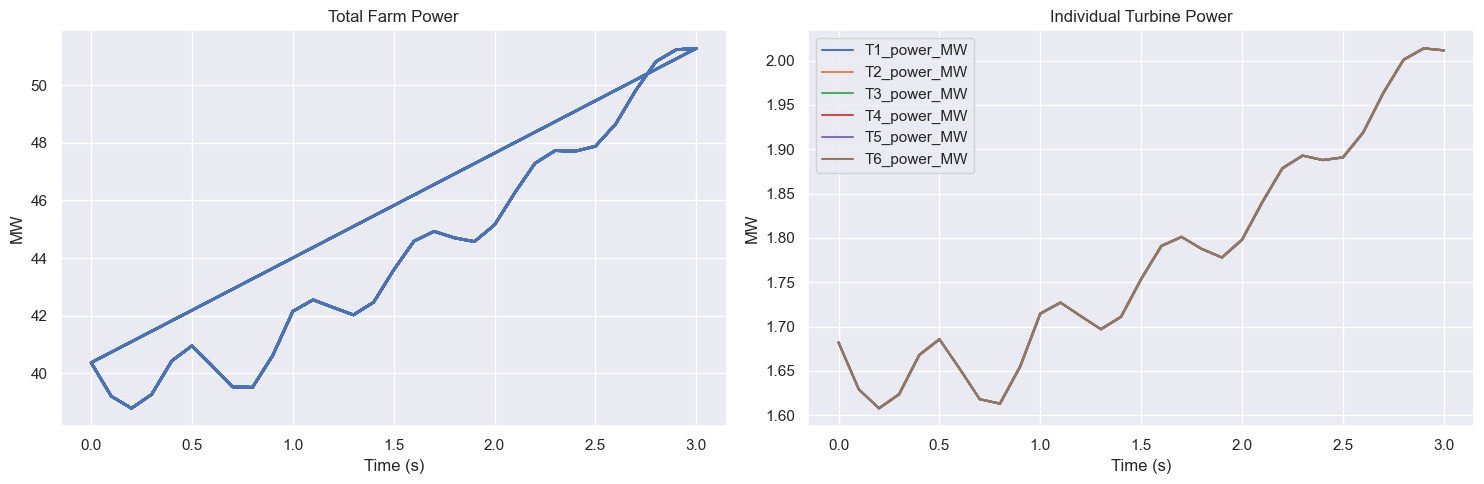

In [12]:
# Plot farm total power and turbine powers
if 'df' in locals():
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
    axes[0].plot(df["time_s"], df["total_MW"], 'b-', lw=2)
    axes[0].set(xlabel="Time (s)", ylabel="MW", title="Total Farm Power")

    # First 6 turbines - melt for seaborn
    plot_cols = [c for c in df.columns if c.startswith("T")][:6]
    df_melt = df.melt(id_vars=["time_s"], value_vars=plot_cols,
                      var_name="Turbine", value_name="Power_MW")
    sns.lineplot(df_melt, x="time_s", y="Power_MW", hue="Turbine", ax=axes[1])
    axes[1].set(xlabel="Time (s)", ylabel="MW", title="Individual Turbine Power")
    axes[1].legend(loc='best')
    plt.tight_layout()